In [85]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [86]:
warnings.filterwarnings('ignore',category=RuntimeWarning)

In [87]:
data = '/content/IMDb Movies India.csv'
df = pd.read_csv(data,encoding='latin1')
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [89]:
df.shape

(15509, 10)

In [90]:
#checking for null values
df.isnull().sum()

,0
Name,0
Year,528
Duration,8269
Genre,1877
Rating,7590
Votes,7589
Director,525
Actor 1,1617
Actor 2,2384
Actor 3,3144


In [91]:
#checking duplicate values
df.duplicated().sum()

np.int64(6)

In [92]:
#dropping null and duplicate values
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

In [93]:
#checking after removing null and duplicate values
df.isnull().sum()

,0
Name,0
Year,0
Duration,0
Genre,0
Rating,0
Votes,0
Director,0
Actor 1,0
Actor 2,0
Actor 3,0


In [94]:
df.shape

(5659, 10)

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5659 entries, 1 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      5659 non-null   object 
 1   Year      5659 non-null   object 
 2   Duration  5659 non-null   object 
 3   Genre     5659 non-null   object 
 4   Rating    5659 non-null   float64
 5   Votes     5659 non-null   object 
 6   Director  5659 non-null   object 
 7   Actor 1   5659 non-null   object 
 8   Actor 2   5659 non-null   object 
 9   Actor 3   5659 non-null   object 
dtypes: float64(1), object(9)
memory usage: 486.3+ KB


In [96]:
#checking datatypes
df.dtypes

,0
Name,object
Year,object
Duration,object
Genre,object
Rating,float64
Votes,object
Director,object
Actor 1,object
Actor 2,object
Actor 3,object


In [97]:
#converting to correct datatypes and removing unwanted symbols and whitespaces
df['Year'] = df['Year'].str.replace(r'\(|\)', '', regex=True).astype(int)
df['Duration'] = pd.to_numeric(df['Duration'].str.replace(r' min', ''))
df['Votes'] = pd.to_numeric(df['Votes'].str.replace(',', ''))

In [98]:
df.dtypes

,0
Name,object
Year,int64
Duration,int64
Genre,object
Rating,float64
Votes,int64
Director,object
Actor 1,object
Actor 2,object
Actor 3,object


In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5659 entries, 1 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      5659 non-null   object 
 1   Year      5659 non-null   int64  
 2   Duration  5659 non-null   int64  
 3   Genre     5659 non-null   object 
 4   Rating    5659 non-null   float64
 5   Votes     5659 non-null   int64  
 6   Director  5659 non-null   object 
 7   Actor 1   5659 non-null   object 
 8   Actor 2   5659 non-null   object 
 9   Actor 3   5659 non-null   object 
dtypes: float64(1), int64(3), object(6)
memory usage: 486.3+ KB


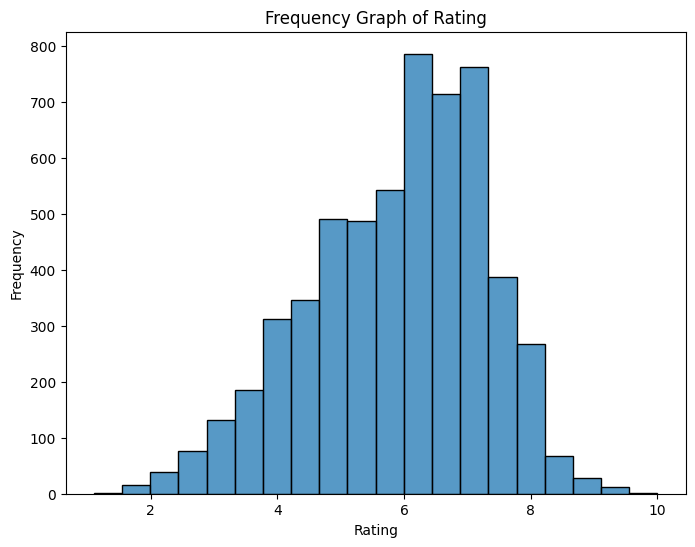

In [100]:
#Frequency graph of rating
plt.figure(figsize=(8,6))
sns.histplot(df['Rating'], bins=20)
plt.title('Frequency Graph of Rating')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

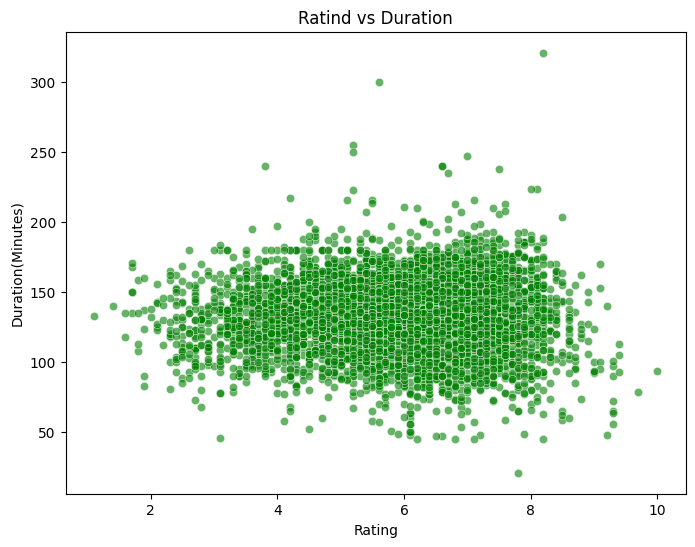

In [101]:
#Duration and Rating
plt.figure(figsize=(8,6))
sns.scatterplot(x = df['Rating'],y = df['Duration'], alpha=0.6, color='Green')
plt.title('Ratind vs Duration')
plt.xlabel('Rating')
plt.ylabel('Duration(Minutes)')
plt.show()

In [102]:

#Dropping irrelevant columns
df.drop(columns=['Name', 'ID'], errors='ignore', inplace=True)

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5659 entries, 1 to 15508
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Year      5659 non-null   int64  
 1   Duration  5659 non-null   int64  
 2   Genre     5659 non-null   object 
 3   Rating    5659 non-null   float64
 4   Votes     5659 non-null   int64  
 5   Director  5659 non-null   object 
 6   Actor 1   5659 non-null   object 
 7   Actor 2   5659 non-null   object 
 8   Actor 3   5659 non-null   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 442.1+ KB


In [104]:
#Again cleaning the data for safety

df['Duration'] = df['Duration'].astype(str).str.extract(r'(\d+)')
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')
df['Duration'].fillna(df['Duration'].median(), inplace=True)

df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df['Year'].fillna(df['Year'].median(), inplace=True)

df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')
df['Votes'].fillna(df['Votes'].median(), inplace=True)

/tmp/ipython-input-1400128397.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Duration'].fillna(df['Duration'].median(), inplace=True)
/tmp/ipython-input-1400128397.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

In [105]:
# converting to numeric values (Label Encoding)
label_encoders = {}
categorical_columns = ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']

for col in categorical_columns:
    df[col]=df[col].astype(str)
    label_encoders[col] = LabelEncoder()
    df[col]=label_encoders[col].fit_transform(df[col])

In [106]:
#Defining features(x) and target variable(y)
X = df.drop(columns=['Rating'])
Y = pd.to_numeric(df['Rating'], errors='coerce')
Y.fillna(Y.median(), inplace=True)

In [107]:
#spliting data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [108]:
#Making the features to a common scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [109]:
#Checking to Nan and Inf values in the sets
print(np.isnan(X_test).sum())
print(np.isnan(Y_test).sum())
print(np.isinf(X_test).sum())
print(np.isinf(Y_test).sum())

0
0
0
0


In [110]:
#Remove any nan and inf values if present
X_test = np.nan_to_num(X_test)
Y_test = np.nan_to_num(Y_test)

In [111]:
#Dropping rows with nan values in X_test
mask = np.isnan(X_test).any(axis=1)
X_test = X_test[~mask]
Y_test = Y_test[~mask]

In [112]:
#final checking
print(np.isnan(X_test).sum())
print(np.isnan(Y_test).sum())

0
0


In [113]:
#Build Neural Network Model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

#Compiling the model
model.compile(optimizer=Adam(learning_rate=0.001), loss="mean_squared_error", metrics=["mae"])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [117]:
#training the model
histroy = model.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, Y_test),
    verbose=1)

Epoch 1/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.1942 - mae: 0.8386 - val_loss: 1.5439 - val_mae: 0.9590
Epoch 2/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2044 - mae: 0.8533 - val_loss: 1.5444 - val_mae: 0.9614
Epoch 3/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.1726 - mae: 0.8341 - val_loss: 1.5561 - val_mae: 0.9599
Epoch 4/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.1424 - mae: 0.8270 - val_loss: 1.5884 - val_mae: 0.9774
Epoch 5/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.1585 - mae: 0.8320 - val_loss: 1.5787 - val_mae: 0.9712
Epoch 6/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.1638 - mae: 0.8301 - val_loss: 1.5413 - val_mae: 0.9642
Epoch 7/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.1896 - mae: 0.8399 - val_loss: 1.5914 - val_mae: 0.9746
Epoch 8/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.1587 - mae: 0.8288 - val_loss: 1.5493 - val_mae: 0.9692
Epoch 9/50
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - lo

In [115]:
Y_pred = model.predict(X_test).flatten()

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


In [116]:
#Model Evaluating
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)

print(f"MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}, R2 Score: {r2:.2f}")

MAE: 0.95, MSE: 1.54, RMSE: 1.24, R2 Score: 0.20


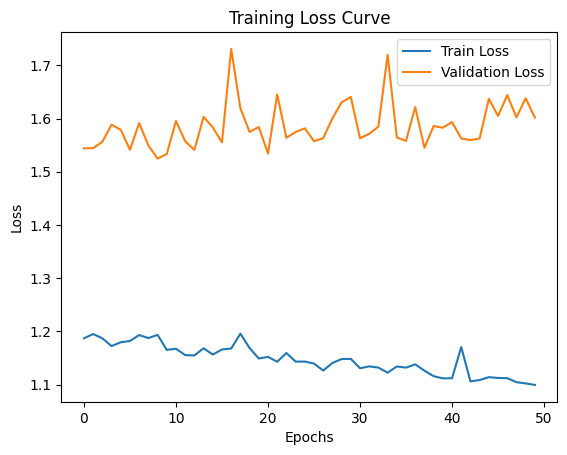

In [118]:
#Evaluation graph
plt.plot(histroy.history["loss"], label="Train Loss")
plt.plot(histroy.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training Loss Curve")
plt.show()

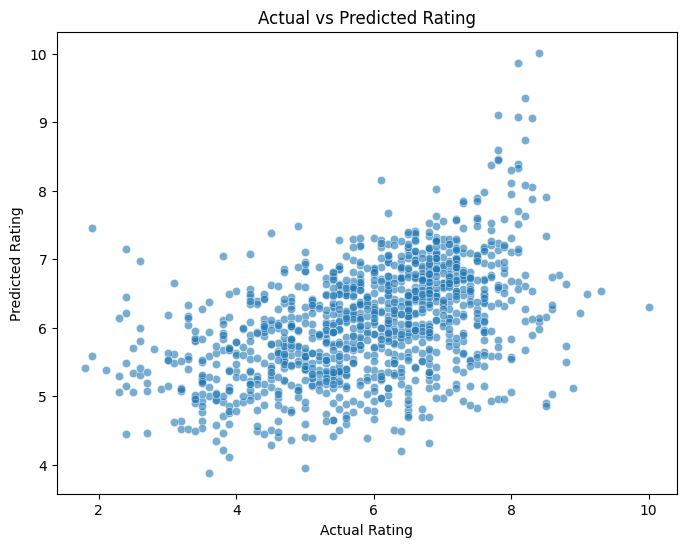

In [119]:
#Scatter Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=Y_test, y=Y_pred, alpha=0.6)
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Actual vs Predicted Rating')
plt.show()

In [131]:
input_data = {
    "Genre": ["Action"],
    "Director": ["John Doe"],
    "Actor 1": ["Actor A"],
    "Actor 2": ["Actor B"],
    "Actor 3": ["Actor C"],
    "Year": [2020],
    "Duration": [120],
    "Votes": [150000]
}

input_df = pd.DataFrame(input_data)

feature_columns = X.columns

input_df = input_df[feature_columns]

#Label encoding of input data
def encode_with_unseen_handling(input_series, label_encoders, column_name):
    if column_name in label_encoders:
        encoder = label_encoders[column_name]
        try:
            return encoder.transform(input_series)
        except ValueError:

            return encoder.transform([encoder.classes_[0]] * len(input_series))
    else:
        raise ValueError(f"Encoder for {column_name} not found in label_encoders.")


categorical_columns = ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']

for col in categorical_columns:
  input_df[col] = encode_with_unseen_handling(input_df[col], label_encoders, col)

input_scaled = scaler.transform(input_df)

predicted_rating = model.predict(input_scaled)

print(f"predicted rating: {predicted_rating[0][0] :.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
predicted rating: 8.53


In [132]:
#Saving the model
model.save("movie_rating_model.h5")

In [133]:
from google.colab import files
files.download("movie_rating_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [134]:
import joblib

# Save encoders, scaler, and feature columns
joblib.dump(scaler, "scaler.pkl")
joblib.dump(label_encoders, "label_encoders.pkl")
joblib.dump(list(X.columns), "feature_columns.pkl")

['feature_columns.pkl']

In [136]:
from google.colab import files
files.download("scaler.pkl")
files.download("label_encoders.pkl")
files.download("feature_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>